In [1]:
import numpy as pd
import pandas as pd

## Dataset tanlovi va asoslash

##**Tanlangan dataset:** Electricity Market Dataset (Avstraliya, New South Wales elektr bozori)

##**Nega Iris emas?**
##Standart topshiriqda Iris yoki Titanic dataseti tavsiya etilgan edi. Biroq, men
##energetika sohasida ishlayotganim sababli, o'zim uchun professional jihatdan
##foydaliroq va real amaliyotga yaqinroq bo'lgan energetika sohasiga oid dataset
##tanladim — bu Iris kabi "o'quv uchun" sun'iy misoldan ko'ra, kelajakdagi
##loyihalarim uchun ham ko'proq amaliy qiymat beradi.

##**Dataset haqida:**
##- Manba: OpenML.org, "electricity" dataseti
##- Hajmi: 45,312 qator, 8 ustun (feature)
##- Kontekst: Avstraliyaning New South Wales elektr bozorida narxlar har
##5 daqiqada talab va taklifga qarab belgilanadi
##- Feature'lar: sana, hafta kuni, vaqt davri, NSW va Viktoriya shtatlaridagi
##  elektr talabi/narxi, shtatlar orasidagi elektr uzatish
##- **Maqsad (target):** narx oxirgi 24 soatlik o'rtachaga nisbatan
##  ko'tarilganmi (UP) yoki tushganmi (DOWN) — binary classification masalasi
##- Sinflar taqsimoti: DOWN — 26,075 (57.5%), UP — 19,237 (42.5%) —
##  nisbatan muvozanatli dataset

In [2]:
from sklearn.datasets import fetch_openml
electricity = fetch_openml(name="electricity", version=1, as_frame=True)

In [3]:
X = electricity.data
y = electricity.target

print(X.shape)
print(y.value_counts())

(45312, 8)
class
DOWN    26075
UP      19237
Name: count, dtype: int64


In [4]:
#Kutubxonadan funksiyani olib kelamiz
from sklearn.model_selection import train_test_split

#Endi funksiyani ishlatamiz - datasetni 80/20 bo'lamiz
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [5]:
#X ichidagi har bir ustunning turini (datatype) tekshiramiz
print(X.dtypes)

date          float64
day          category
period        float64
nswprice      float64
nswdemand     float64
vicprice      float64
vicdemand     float64
transfer      float64
dtype: object


In [6]:
# "day" ustunini category formatidan oddiy (int) butun son formatiga o'tkizamiz

X['day'] = X['day'].astype(int)

#Qayta tekkshiramiz, endi hammasi raqam bo'lishi kerak
print(X.dtypes)

date         float64
day            int64
period       float64
nswprice     float64
nswdemand    float64
vicprice     float64
vicdemand    float64
transfer     float64
dtype: object


/tmp/ipykernel_907/4245933474.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['day'] = X['day'].astype(int)


In [7]:
# X ni asl nusxxa ekanligini pandasga bildiramiz
X = X.copy()

#Endi xavfsiz tarzda o'zgartiramiz
X['day'] = X['day'].astype(int)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (36249, 8)
Test: (9063, 8)


In [9]:
#kerakli kutubxonalarni import qilamiz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Modelni sozlamalarsiz (default hyperparametrlar bilan yaratmiz)
baseline_model = RandomForestClassifier(random_state=42)

#Modelni faqat train qismida o'qitamiz
baseline_model.fit(X_train, y_train)

#MOdelni hali ko'rmagan test qismida bashorat qilamiz
y_pred_baseline = baseline_model.predict(X_test)

#bashoratni haqiqiy javoblar bilan solishtirib, aniqlikni hisoblaymmiz
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.9062120710581485


In [10]:
# GridSearch sinab ko'radigan hyperparametr qiymatlari lug'ati (dictionary)
param_grid = {
    "n_estimators": [50, 100, 200],   # daraxtlar soni - 3 ta variant
    "max_depth": [5, 10, 20, None]     # daraxt chuqurligi - 4 ta variant (None = chegarasiz)
}

In [11]:
# Kerakli kutubxonani import qilamiz
from sklearn.model_selection import GridSearchCV

# Yangi, "sozlanmagan" RandomForest obyekti yaratamiz
# (bu - GridSearch ichida turli parametrlar bilan sinaladigan "asos" model)
model = RandomForestClassifier(random_state=42)

# GridSearchCV obyektini yaratamiz
grid_search = GridSearchCV(
    estimator=model,       # qaysi model bilan ishlaymiz
    param_grid=param_grid, # qaysi hyperparametrlarni sinaymiz
    cv=5,                  # 5-fold Cross Validation
    scoring="accuracy",    # qaysi mezon bo'yicha baholaymiz
    n_jobs=-1,              # kompyuterning barcha yadrolarini ishlatib, tezroq hisoblash
    verbose=1               # jarayon haqida qisqacha xabar chiqarib turadi
)

# Barcha kombinatsiyalarni SINAB KO'RISH jarayoni shu yerda boshlanadi
# DIQQAT: faqat TRAIN qismi beriladi, test emas!
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [12]:
#Grid Searchtopgan eng yaxshi parametrlar kombinatsiyasi
print("Eng yaxshi parametrlar:", grid_search.best_params_)

#O'sha kombinatsiyaning Cross-Validation'dagi o'rtacha accuracy'si
print("Eng yaxshi CV accuracy:", grid_search.best_score_)

Eng yaxshi parametrlar: {'max_depth': None, 'n_estimators': 200}
Eng yaxshi CV accuracy: 0.9006315867586968


In [13]:
# GridSearch topgan ENG YAXSHI modelni alohida o'zgaruvchiga olamiz
best_model = grid_search.best_estimator_

# Bu model bilan, hali ko'rmagan TEST to'plamida bashorat qilamiz
y_pred_best = best_model.predict(X_test)

# Haqiqiy test accuracy'sini hisoblaymiz
best_test_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned model - Test accuracy:", best_test_accuracy)
print("Baseline model - Test accuracy:", baseline_accuracy)

Tuned model - Test accuracy: 0.9064327485380117
Baseline model - Test accuracy: 0.9062120710581485


In [14]:
import pandas as pd

# Ikkala modelning natijalarini bitta jadvalga jamlaymiz
comparison = pd.DataFrame({
    "Model": ["Baseline (default)", "Tuned (GridSearchCV)"],
    "Test Accuracy": [baseline_accuracy, best_test_accuracy]
})

print(comparison)

                  Model  Test Accuracy
0    Baseline (default)       0.906212
1  Tuned (GridSearchCV)       0.906433


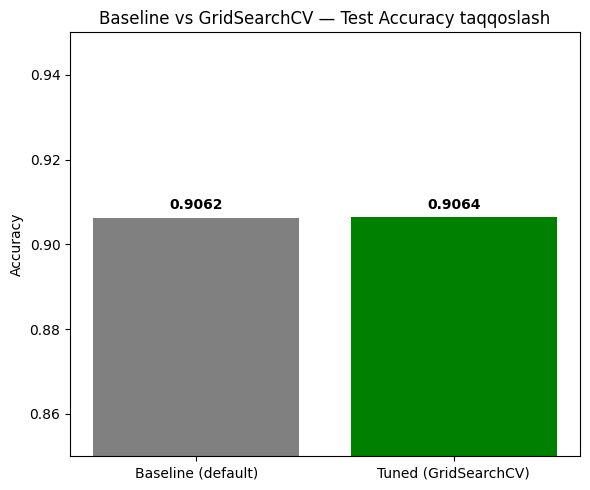

In [15]:
import matplotlib.pyplot as plt

# Grafik o'lchamini belgilaymiz
plt.figure(figsize=(6, 5))

# Bar chart chizamiz - x o'qida model nomlari, y o'qida accuracy
plt.bar(comparison["Model"], comparison["Test Accuracy"], color=["gray", "green"])

# Grafikka sarlavha va o'q nomlarini qo'shamiz
plt.title("Baseline vs GridSearchCV — Test Accuracy taqqoslash")
plt.ylabel("Accuracy")
plt.ylim(0.85, 0.95)  # farqni yaxshiroq ko'rish uchun, 0dan emas 0.85dan boshlaymiz

# Har bir bar ustiga aniq raqamni yozamiz
for i, val in enumerate(comparison["Test Accuracy"]):
    plt.text(i, val + 0.002, f"{val:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

Nega GridSearch vaqt oladi?

Kombinatsiyalar hisobi:

Bizning param_gridda 2 ta hyperparametr bor:

n_estimators: 3 ta qiymat (50, 100, 200)
max_depth: 4 ta qiymat (5, 10, 20, None)

Kombinatsiyalar soni: 3 × 4 = 12 ta turli sozlama variantlari.

Nega har biri 5 marta sinaladi:

Biz cv=5 (5-fold Cross Validation) ishlatganimiz uchun, har bir 12 ta kombinatsiyaning har biri alohida 5 marta o'qitiladi — chunki ma'lumot 5 qismga bo'linib, har safar boshqa qismi "validation" bo'lib, qolgan 4 qismi "train" bo'lib ishlatiladi. Bu — natijaning tasodifga bog'liq bo'lib qolmasligi uchun kerak (bitta noqulay train/test bo'linishi natijani buzib yubormasin, deb).

Shuning uchun jami fit soni: 12 × 5 = 60 marta model to'liq qaytadan o'qitiladi.

Nega bu vaqt oladi va son qanday tez o'sadi:

GridSearch — bu aslida 60 marta RandomForest'ni noldan o'qitish degani, va har bir o'qitish o'zi vaqt talab qiladi. Eng muhimi, bu son ko'paytirish orqali o'sadi, qo'shish orqali emas — shuning uchun bir necha yangi qiymat qo'shish darrov sonni "portlatib" yuboradi:

Agar biz yana bitta hyperparametr — min_samples_split=[2, 5, 10] (3 ta qiymat) qo'shsak:
Kombinatsiyalar: 3 × 4 × 3 = 36 ta
Jami fit: 36 × 5 = 180 marta (avvalgi 60 tadan 3 barobar ko'p!)

Bu — GridSearch'ning asosiy kamchiligi: hyperparametrlar yoki ularning qiymatlari sonini ozgina oshirsak ham, sinaladigan kombinatsiyalar soni exponentsial (ko'rsatkichli) tezlikda o'sadi, va har bir kombinatsiya haqiqiy model o'qitishni talab qilgani uchun, hisoblash vaqti ham shu tezlikda o'sadi.

In [16]:
import joblib
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [17]:
%%writefile app.py

import streamlit as st

Writing app.py


In [18]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# Sahifa sozlamalari - brauzer tabidagi nom va layout
st.set_page_config(page_title="Electricity Price GridSearch", layout="wide")

# Sarlavha va qisqa tavsif
st.title("⚡ Electricity Market — GridSearchCV bilan Hyperparameter Tuning")
st.markdown("""
Bu ilova Avstraliya elektr bozori ma'lumotlari asosida, narx **UP** yoki **DOWN**
bo'lishini bashorat qiluvchi RandomForest modelini ko'rsatadi. Model
**GridSearchCV** yordamida sozlangan.
""")

Overwriting app.py


In [19]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# Sahifa sozlamalari
st.set_page_config(page_title="Electricity Price GridSearch", layout="wide")

# Sarlavha va tavsif
st.title("⚡ Electricity Market — GridSearchCV bilan Hyperparameter Tuning")
st.markdown("""
Bu ilova Avstraliya elektr bozori ma'lumotlari asosida, narx **UP** yoki **DOWN**
bo'lishini bashorat qiluvchi RandomForest modelini ko'rsatadi. Model
**GridSearchCV** yordamida sozlangan.
""")

# Saqlangan modelni yuklaymiz
best_model = joblib.load("best_model.pkl")

# Baseline va Tuned natijalarini qo'lda kiritamiz
# (bu raqamlar - sizning notebook'ingizda hisoblangan aniq natijalar)
comparison = pd.DataFrame({
    "Model": ["Baseline (default)", "Tuned (GridSearchCV)"],
    "Test Accuracy": [0.9062120710581485, 0.9064327485380117]
})

# Ikki ustunli joylashuv - chapda jadval, o'ngda grafik
col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 Natijalar jadvali")
    st.dataframe(comparison)

with col2:
    st.subheader("📈 Taqqoslash grafigi")
    st.bar_chart(comparison.set_index("Model"))

# Eng yaxshi hyperparametrlarni ko'rsatamiz
st.subheader("🏆 GridSearch topgan eng yaxshi parametrlar")
st.json({"n_estimators": 200, "max_depth": "None"})

Overwriting app.py


In [20]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Writing requirements.txt
